# Explore Nasdaq Financial Data using Nasdaq Data Link API

## Introduction
We will focus on the MER/F1 datatable, which contains detailed financial information such as balance sheets, cash flow statements, and income statements.

We will extract financial data for a specific set of companies, with an emphasis on understanding their financial performance over time. We'll be looking at metrics like Accrued Expenses Turnover and exploring how these values differ among companies and regions.

Let's configure 'config.py' file with 'api_key' first.

## Configuring 'config.py' with 'api_key'

In [1]:
config_content="""api_key='your api key'"""

In [2]:
config_file_path='your path/config.py'
with open(config_file_path,'w') as file:
    file.write(config_content)

In [3]:
import sys
sys.path.append('C:/Users/Public/Documents/yang/Data Science Project')

import config

api_key=config.api_key

## Extract Data 

In [4]:
import requests
import json
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
#base_url

base_url='https://data.nasdaq.com/api/v3/datatables/MER/F1.json'



In [6]:
#Parameters

parameter={
    'api_key': api_key,
    'qopts.per_page':10    #only sample 10 rows first
}

In [7]:
#sampling data to explore the data structure
json_data=requests.get(base_url,params=parameter).json() 

In [8]:
print(json_data)

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2023-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1868216112, -1802, 8.161754, '2011-09-30', 'Q3', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2023-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1885063456, -1802, 10.788213, '2012-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60

The data is stored in 'datatable'/'data'. The columns is stored in 'columns'

In [9]:
# extract 10,000 rows with updated parameters

parameters={
    'api_key':api_key,
    'qopts.per_page':10000
}

In [10]:
# extract json data

json_data=requests.get(base_url,params=parameters).json()

In [11]:
data=json_data['datatable']['data'] #data values
columns=[col['name'] for col in json_data['datatable']['columns']] #columns

In [12]:
df=pd.DataFrame(data,columns=columns)

In [13]:
df.head()

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 non-null  object 
 18  address

In [15]:
#We will only keep those columns for the purpose of analysis
necessary_cols=['reportid','reportdate','reporttype','amount','longname','country','region','indicator','statement']

## Filter the data columns and rows

In [16]:
df_subset=df[necessary_cols]

Since we will only focus on "Accrued Expenses Turnover", let's check 'indicator'column first


In [17]:
df_subset['indicator'].unique()

array(['Accrued Expenses Turnover', 'Cash Flow Per Share',
       'Operating Income', 'Operating Margin', 'Interest Coverage',
       'Return on Investment', 'Total Assets Per Share',
       'Free Cash Flow Per Share', 'Revenue Per Share', 'Net Income',
       'Cash, Beginning of Year', 'Quick Ratio', 'PP&E Turnover',
       'Gross Margin', 'Current Liabilities', 'Return on Equity',
       'Current Ratio', 'Total Assets', 'Calculated Tax Rate',
       'Current Assets', 'Return on Assets', 'Inventory Turnover',
       'Total Debt to Equity', 'Long Term Debt to Equity',
       'Total Liabilities', 'Total Revenue', "Stockholders' Equity",
       'Cash & Equivalents Turnover', 'Cash From Operations',
       'Accounts Payable Turnover', 'Cash From Investing',
       'Total Asset Turnover', 'Cash From Financing',
       'Net Current Assets as % of Total Assets', 'Revenue to Assets',
       'Receivables Turnover', 'Net Margin', 'Cash, End of Year',
       'EPS - Net Income - Basic', 'Shares O

In [18]:
#we only need 'indictor' columns with 'Accrued Expenses Turnover'
df_fn=df_subset[df_subset['indicator']=='Accrued Expenses Turnover']

In [19]:
#statistics summary of 'Accure Expenses Turnover'
df_fn['amount'].describe() 

count    139.000000
mean      26.908762
std       33.097291
min        4.689773
25%        9.675670
50%       13.753753
75%       31.777614
max      229.810427
Name: amount, dtype: float64

In [20]:
#let's rename the country names
country_mapping = {
    'USA': 'United States of America',
    'DEU': 'Germany',
    'JPN': 'Japan',
    'CYM': 'Cayman Islands',
    'BHS': 'Bahama',
    'IRL': 'Ireland',
    'GBR': 'United Kingdom'

}

In [21]:
df_fn['country_name']=df_fn['country'].map(country_mapping)

C:\Users\Nicole\AppData\Local\Temp\ipykernel_272\3935023478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['country_name']=df_fn['country'].map(country_mapping)


In [22]:
df_fn['country_name'].unique()

array(['Germany', 'Bahama', 'United Kingdom', 'Japan', 'Cayman Islands',
       'United States of America', 'Ireland'], dtype=object)

In [23]:
#change the 'company_name' for the columns
df_fn.rename(columns={'longname':'company_name'},inplace=True)

C:\Users\Nicole\AppData\Local\Temp\ipykernel_272\2927576939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn.rename(columns={'longname':'company_name'},inplace=True)


In [24]:
#convert ' reportdate' column to datetime object
df_fn['reportdate']=pd.to_datetime(df_fn['reportdate'])

C:\Users\Nicole\AppData\Local\Temp\ipykernel_272\1350130015.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['reportdate']=pd.to_datetime(df_fn['reportdate'])


In [25]:
df_fn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 9386
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   reportid      139 non-null    int64         
 1   reportdate    139 non-null    datetime64[ns]
 2   reporttype    139 non-null    object        
 3   amount        139 non-null    float64       
 4   company_name  139 non-null    object        
 5   country       139 non-null    object        
 6   region        139 non-null    object        
 7   indicator     139 non-null    object        
 8   statement     139 non-null    object        
 9   country_name  139 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 11.9+ KB


In [26]:
#check the range of years
df_fn['reportdate'].dt.year.unique() 

array([2011, 2012, 2013, 2010, 2014, 2015])

## Visualize the Financial Trend of Each Company from 2010 to 2015

In [27]:
comp_name=list(df_fn['company_name'].unique())

In [28]:
comp_name

['Deutsche Bank AG',
 'Ultrapetrol (Bahamas) Ltd',
 'Capri Holdings Ltd',
 'Canon Inc',
 'Herbalife Ltd (New)',
 'Apple Inc',
 'Accenture plc',
 'Nielsen Holdings PLC']

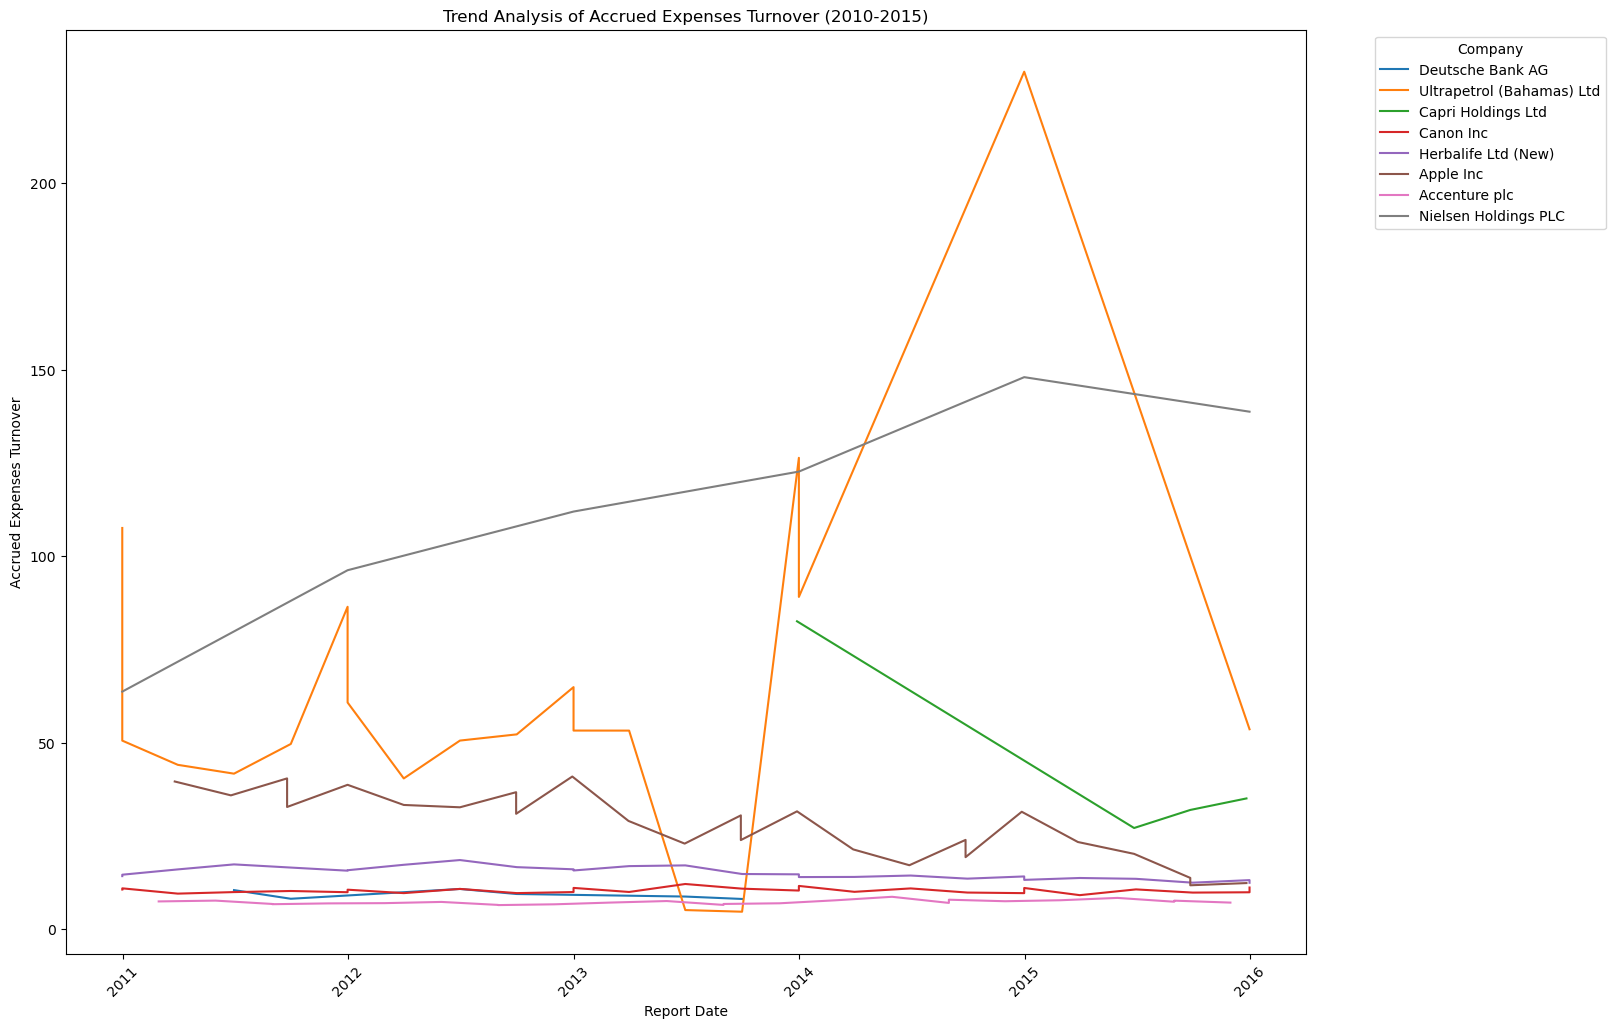

In [29]:
plt.figure(figsize=(16,12))

for c in comp_name:
    company=df_fn[df_fn['company_name']==c]
    plt.plot(company['reportdate'],company['amount'],label=c)
    
    plt.title('Trend Analysis of Accrued Expenses Turnover (2010-2015)')
    plt.xlabel('Report Date')
    plt.ylabel('Accrued Expenses Turnover')
    plt.xticks(rotation=45)
    plt.legend(title='Company',bbox_to_anchor=(1.05,1),loc='upper left')
    
plt.show()

## Visualize the differences among the Regions

In [30]:
df_fn['region'].unique()

array(['Europe', 'Latin America', 'Asia Pacific', 'North America'],
      dtype=object)

In [31]:
avg_by_region=df_fn.groupby('region')['amount'].mean()

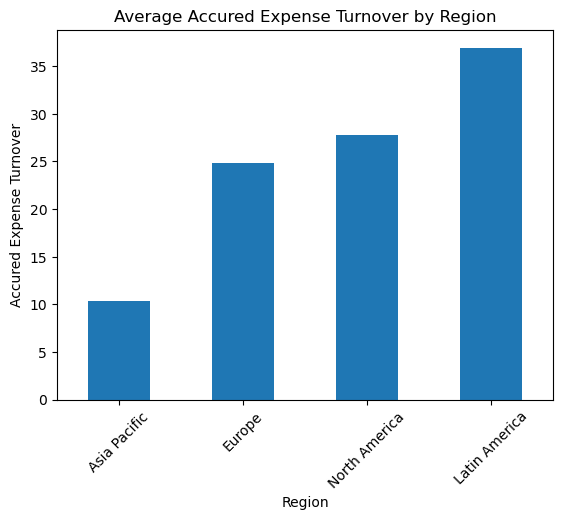

In [33]:
#ploting the Accured Expense Turnover among regions
avg_by_region.sort_values(ascending=True).plot(kind='bar')
plt.title('Average Accured Expense Turnover by Region')
plt.xlabel('Region')
plt.ylabel('Accured Expense Turnover')
plt.xticks(rotation=45)

plt.show()